In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_classification

In [3]:
?make_classification

Signature:
make_classification(
    n_samples=100,
    n_features=20,
    *,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=None,
    flip_y=0.01,
    class_sep=1.0,
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=None,
)
Docstring:
Generate a random n-class classification problem.

This initially creates clusters of points normally distributed (std=1)
about vertices of an ``n_informative``-dimensional hypercube with sides of
length ``2*class_sep`` and assigns an equal number of clusters to each
class. It introduces interdependence between these features and adds
various types of further noise to the data.

Without shuffling, ``X`` horizontally stacks features in the following
order: the primary ``n_informative`` features, followed by ``n_redundant``
linear combinations of the informative features, followed by ``n_repeated``
duplicates, drawn randomly with replacement from the infor

In [15]:
def make_data(sep):

    X, y = make_classification(n_samples=1000,
                               n_features=2,
                               n_redundant=0,
                               n_clusters_per_class=1,
                               weights=[0.99],
                               class_sep=sep,
                               random_state=0)
    
    X = pd.DataFrame(X, columns=['varA', 'varB'])
    y = pd.Series(y)

    return X, y

# Undersampleing with Edited Nearest Neighbours

In [16]:
X,y = make_data(sep=2)

In [6]:
import imblearn.under_sampling

In [7]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [8]:
from imblearn.under_sampling import EditedNearestNeighbours

In [9]:
help(EditedNearestNeighbours)

Help on class EditedNearestNeighbours in module imblearn.under_sampling._prototype_selection._edited_nearest_neighbours:

class EditedNearestNeighbours(imblearn.under_sampling.base.BaseCleaningSampler)
 |  EditedNearestNeighbours(*, sampling_strategy='auto', n_neighbors=3, kind_sel='all', n_jobs=None)
 |  
 |  Undersample based on the edited nearest neighbour method.
 |  
 |  This method cleans the dataset by removing samples close to the
 |  decision boundary. It removes observations from the majority class or
 |  classes when any or most of its closest neighours are from a different class.
 |  
 |  Read more in the :ref:`User Guide <edited_nearest_neighbors>`.
 |  
 |  Parameters
 |  ----------
 |  sampling_strategy : str, list or callable
 |      Sampling information to sample the data set.
 |  
 |      - When ``str``, specify the class targeted by the resampling. Note the
 |        the number of samples will not be equal in each. Possible choices
 |        are:
 |  
 |          ``'

In [10]:
?EditedNearestNeighbours

Init signature:
EditedNearestNeighbours(
    *,
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=None,
)
Docstring:     
Undersample based on the edited nearest neighbour method.

This method cleans the dataset by removing samples close to the
decision boundary. It removes observations from the majority class or
classes when any or most of its closest neighours are from a different class.

Read more in the :ref:`User Guide <edited_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all 

In [11]:
enn = EditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=-1
)

X_resampled, y_resampled = enn.fit_resample(X, y)

In [12]:
X.shape, y.shape

((1000, 2), (1000,))

In [13]:
X_resampled.shape, y_resampled.shape

((985, 2), (985,))

In [17]:
y.value_counts()

0    984
1     16
Name: count, dtype: int64

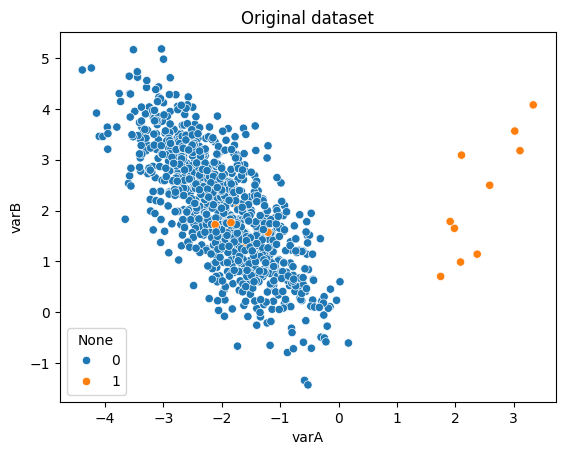

In [18]:
sns.scatterplot(
    data=X, x='varA', y='varB', hue=y
)

plt.title('Original dataset')
plt.show()

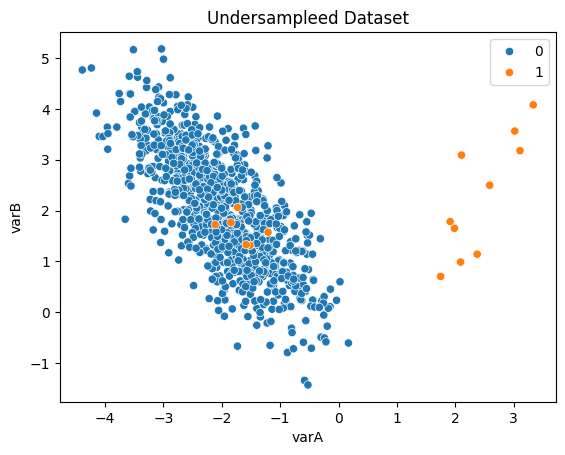

In [19]:
sns.scatterplot(
    data=X_resampled, x='varA', y='varB', hue=y_resampled
)
plt.title('Undersampleed Dataset')
plt.show()

# Partially separated classes

In [20]:
X, y = make_data(sep=0.1)


In [21]:
?EditedNearestNeighbours

Init signature:
EditedNearestNeighbours(
    *,
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=None,
)
Docstring:     
Undersample based on the edited nearest neighbour method.

This method cleans the dataset by removing samples close to the
decision boundary. It removes observations from the majority class or
classes when any or most of its closest neighours are from a different class.

Read more in the :ref:`User Guide <edited_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all 

In [23]:
enn = EditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=-1
)

In [24]:
X_resampled, y_resampled = enn.fit_resample(X, y)

In [25]:

X.shape, y.shape

((1000, 2), (1000,))

In [26]:
X_resampled.shape, y_resampled.shape

((965, 2), (965,))

<Axes: xlabel='varA', ylabel='varB'>

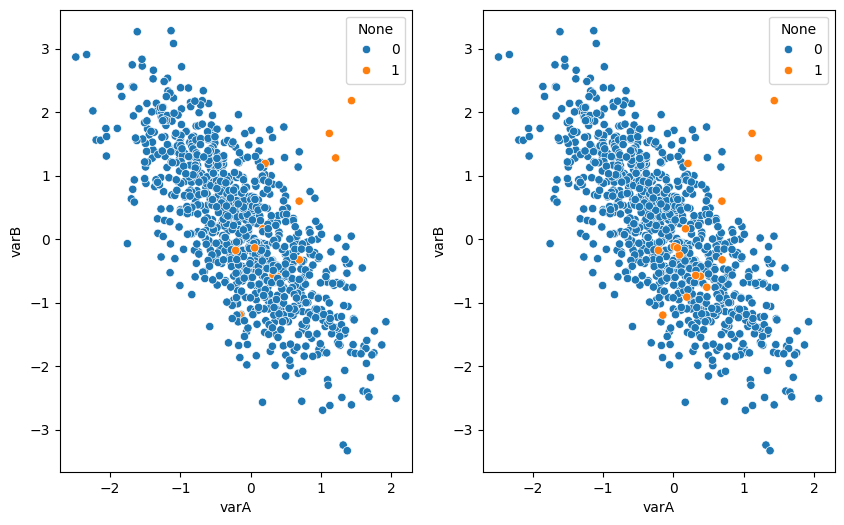

In [28]:
plt.figure(figsize=(10,6))
plt.subplot(121)
sns.scatterplot(data=X, x='varA', y='varB', hue=y)

plt.subplot(122)
sns.scatterplot(data=X_resampled, x='varA', y='varB', hue=y_resampled)

In [29]:
?EditedNearestNeighbours

Init signature:
EditedNearestNeighbours(
    *,
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=None,
)
Docstring:     
Undersample based on the edited nearest neighbour method.

This method cleans the dataset by removing samples close to the
decision boundary. It removes observations from the majority class or
classes when any or most of its closest neighours are from a different class.

Read more in the :ref:`User Guide <edited_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all 

In [30]:
enn = EditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='mode',
    n_jobs=-1
)

X_resampled_mode, y_resampled_mode = enn.fit_resample(X,y)

In [34]:
enn = EditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=5,
    kind_sel='mode',
    n_jobs=-1
)

X_resampled_5_mode, y_resampled_5_mode = enn.fit_resample(X,y)

Text(0.5, 1.0, 'EditedNearestNeighbours, n_neighbors=5, kind_sel=Mode')

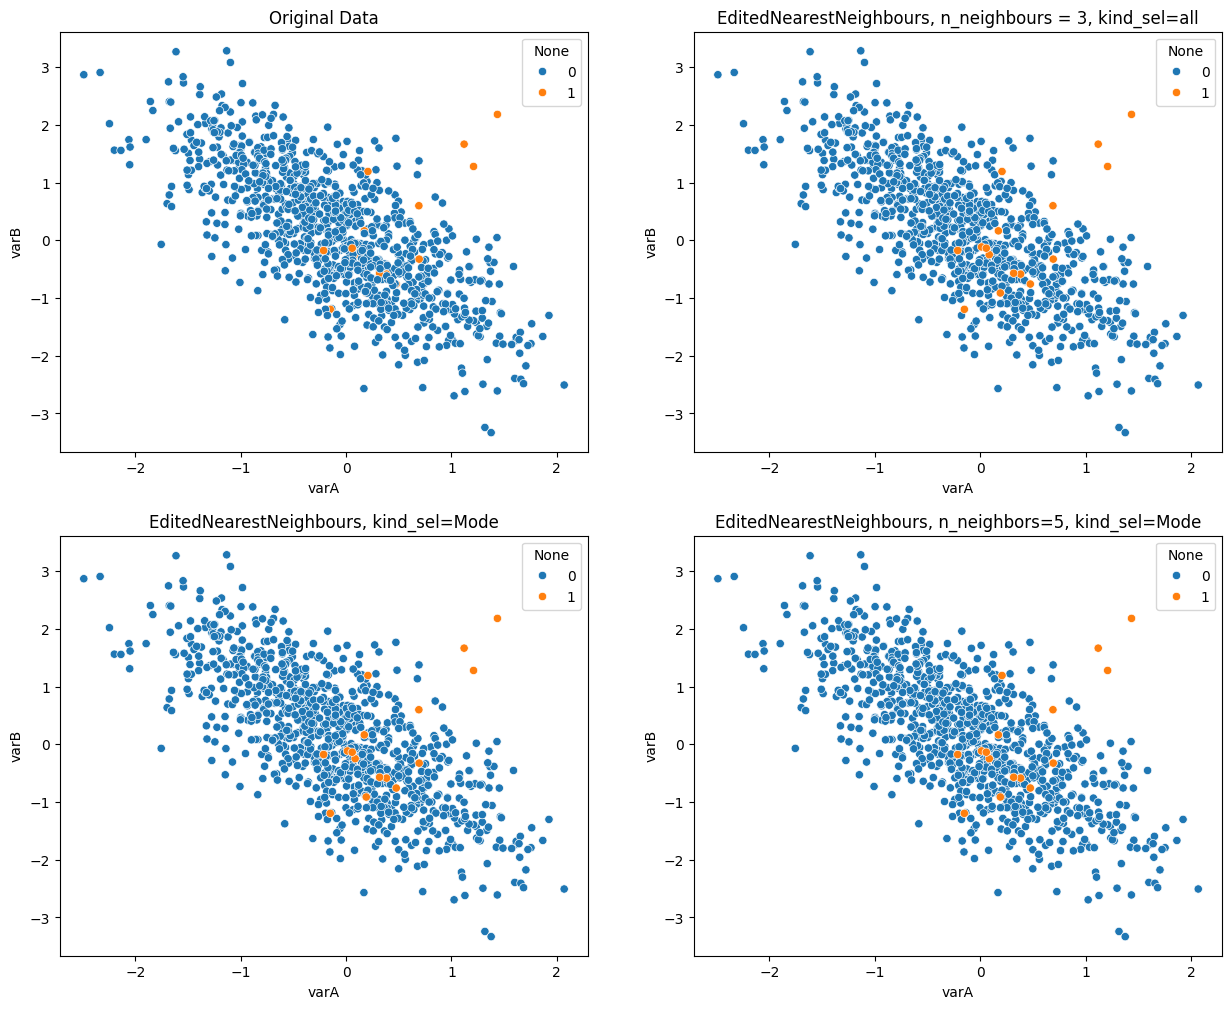

In [35]:
plt.figure(figsize=(15,12))
plt.subplot(221)
sns.scatterplot(data=X, x='varA', y='varB', hue=y)
plt.title('Original Data')

plt.subplot(222)
sns.scatterplot(data=X_resampled, x='varA', y='varB', hue=y_resampled)
plt.title('EditedNearestNeighbours, n_neighbours = 3, kind_sel=all')

plt.subplot(223)
sns.scatterplot(data=X_resampled_mode, x='varA', y='varB', hue=y_resampled_mode)
plt.title('EditedNearestNeighbours, kind_sel=Mode')

plt.subplot(224)
sns.scatterplot(data=X_resampled_5_mode, x='varA', y='varB', hue=y_resampled_5_mode)
plt.title('EditedNearestNeighbours, n_neighbors=5, kind_sel=Mode')

In [37]:
df= pd.read_csv('../kdd2004.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,target
0,52.0,32.69,0.30,2.5,20.0,1256.8,-0.89,0.33,11.0,-55.0,...,1595.1,-1.64,2.83,-2.0,-50.0,445.2,-0.35,0.26,0.76,-1
1,58.0,33.33,0.00,16.5,9.5,608.1,0.50,0.07,20.5,-52.5,...,762.9,0.29,0.82,-3.0,-35.0,140.3,1.16,0.39,0.73,-1
2,77.0,27.27,-0.91,6.0,58.5,1623.6,-1.40,0.02,-6.5,-48.0,...,1491.8,0.32,-1.29,0.0,-34.0,658.2,-0.76,0.26,0.24,-1
3,41.0,27.91,-0.35,3.0,46.0,1921.6,-1.36,-0.47,-32.0,-51.5,...,2047.7,-0.98,1.53,0.0,-49.0,554.2,-0.83,0.39,0.73,-1
4,50.0,28.00,-1.32,-9.0,12.0,464.8,0.88,0.19,8.0,-51.5,...,479.5,0.68,-0.59,2.0,-36.0,-6.9,2.02,0.14,-0.23,-1


In [38]:
df.target = df.target.map({-1:0, 1:1})
df.target.value_counts()

target
0    144455
1      1296
Name: count, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [40]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df.target, test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((102025, 74), (43726, 74))

In [41]:
from imblearn.under_sampling import EditedNearestNeighbours

In [42]:
?EditedNearestNeighbours

Init signature:
EditedNearestNeighbours(
    *,
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=None,
)
Docstring:     
Undersample based on the edited nearest neighbour method.

This method cleans the dataset by removing samples close to the
decision boundary. It removes observations from the majority class or
classes when any or most of its closest neighours are from a different class.

Read more in the :ref:`User Guide <edited_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all 

In [43]:
enn = EditedNearestNeighbours(sampling_strategy='auto',
                              n_neighbors=3,
                              kind_sel='all',
                              n_jobs=-1)


In [44]:
X_resampled, y_resampled = enn.fit_resample(X_train, y_train)

In [45]:
X_train.shape, X_resampled.shape

((102025, 74), (101230, 74))

# Plotting the data

In [47]:
X_train.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',
       '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72',
       '73'],
      dtype='object')

<Axes: xlabel='0', ylabel='1'>

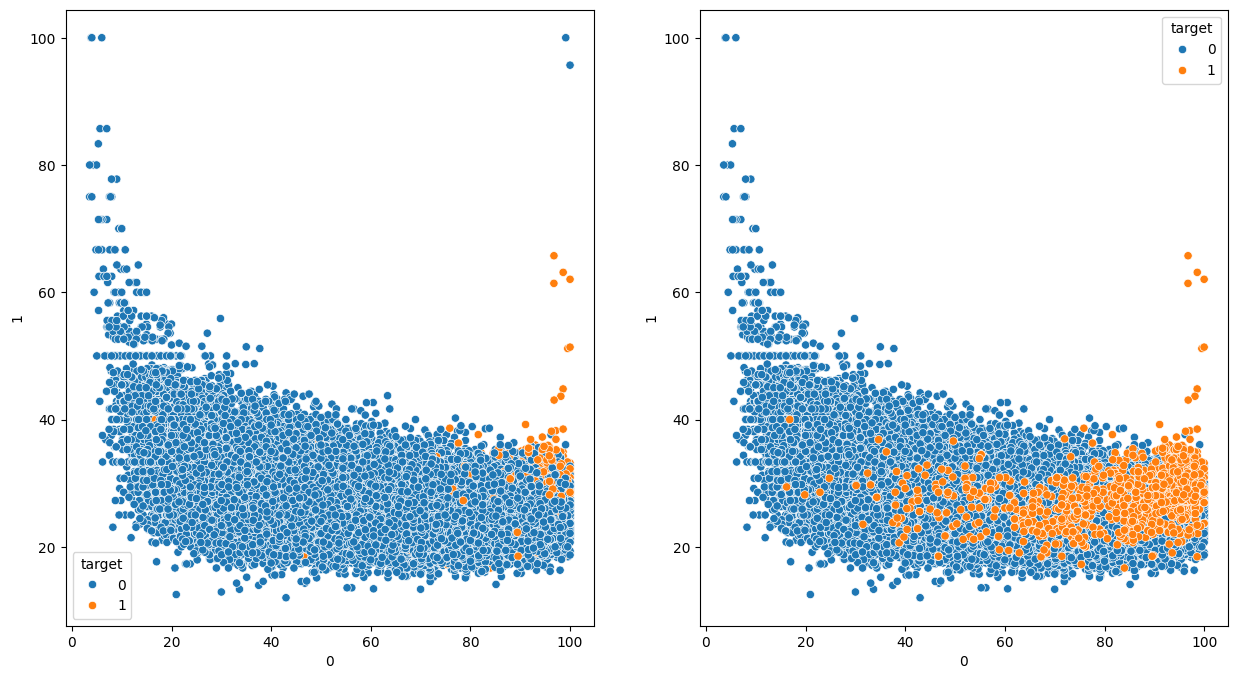

In [49]:
plt.figure(figsize=(15,8))
plt.subplot(121)
sns.scatterplot(data=X_train, x='0', y='1', hue=y_train)

plt.subplot(122)
sns.scatterplot(data=X_resampled, x='0', y='1', hue=y_resampled)

<Axes: xlabel='4', ylabel='5'>

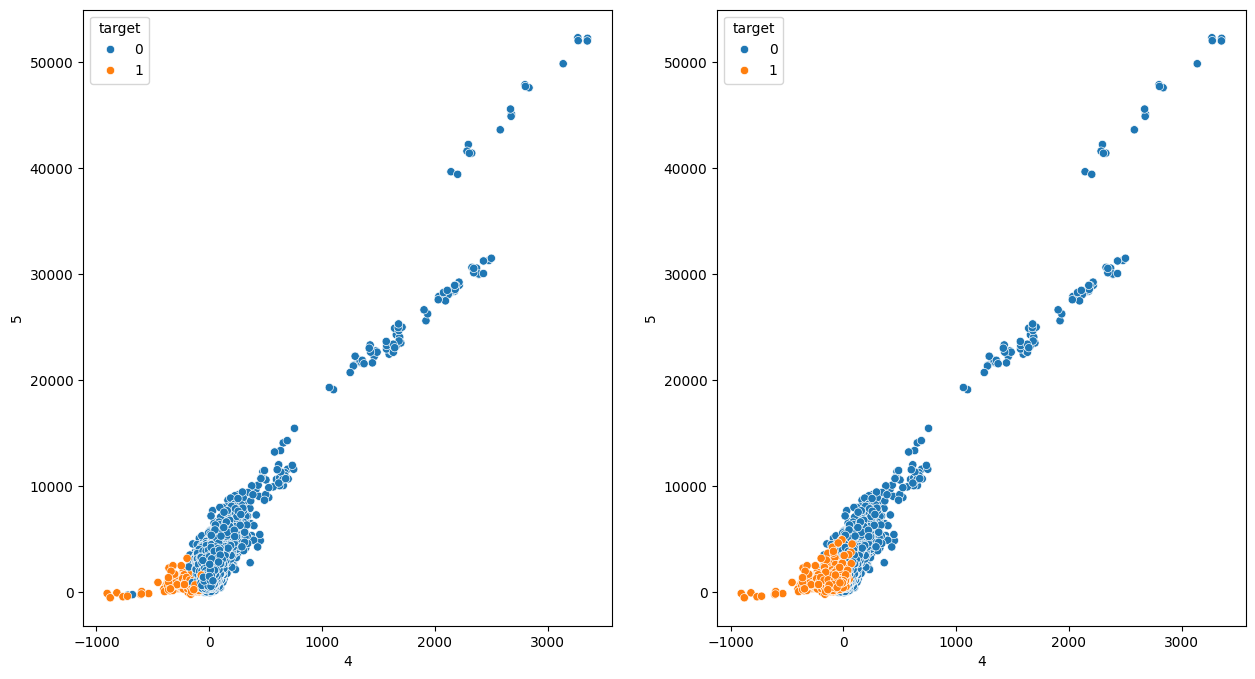

In [50]:
plt.figure(figsize=(15,8))
plt.subplot(121)
sns.scatterplot(data=X_train, x='4', y='5', hue=y_train)

plt.subplot(122)
sns.scatterplot(data=X_resampled, x='4', y='5', hue=y_resampled)

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
from sklearn.metrics import roc_auc_score

In [53]:
def runRandomForests(X_train, X_test, y_train, y_test):
    rf = RandomForestClassifier(n_estimators=200, criterion='entropy', max_depth=4, random_state=0)
    rf.fit(X_train, y_train)

    pred = rf.predict_proba(X_train)[:,1]
    print("RF's train ROC-AUC: {}".format(roc_auc_score(y_train, pred)))

    pred = rf.predict_proba(X_test)[:,1]
    print("RF's test ROC-AUC: {}".format(roc_auc_score(y_test, pred)))



In [54]:
runRandomForests(X_train, X_test, y_train, y_test)

RF's train ROC-AUC: 0.9864891279911616
RF's test ROC-AUC: 0.9863127995688801


In [55]:
runRandomForests(X_resampled, X_test, y_resampled, y_test)

RF's train ROC-AUC: 0.9866540642709432
RF's test ROC-AUC: 0.9869454582657571


In [56]:
from matplotlib.colors import ListedColormap

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


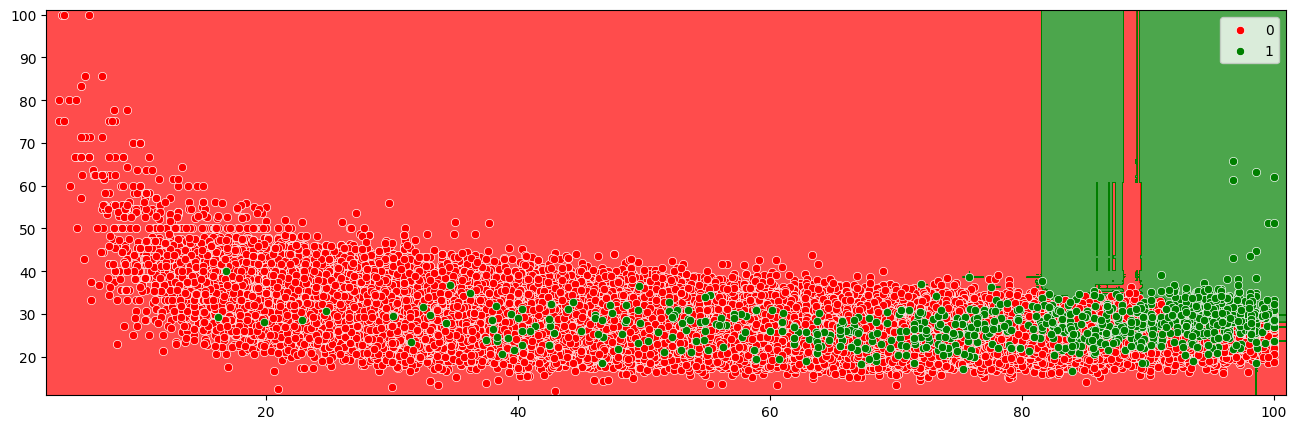

In [58]:
X_train2D = X_train.iloc[:,:2]
y_train = y_train

enn = EditedNearestNeighbours(sampling_strategy='auto',
                              n_neighbors=3,
                              kind_sel='all',
                              n_jobs=-1)

X_resampled, y_resampled = enn.fit_resample(X_train2D, y_train)

rf_oss = RandomForestClassifier()

rf_oss.fit(X_resampled, y_resampled)

plt.figure(figsize=(16,5))
X_set, y_set = X_resampled.values, y_resampled

colors=('red', 'green')
cmap=ListedColormap(colors)


X1_min, X1_max = X_set[:,0].min() - 1, X_set[:,0].max() + 1
X2_min, X2_max = X_set[:,1].min() - 1, X_set[:,1].max() + 1
step=0.01

X1, X2 = np.meshgrid(
                    np.arange(X1_min, X1_max, step),
                    np.arange(X2_min, X2_max, step)
)


arr = np.array([X1.ravel(), X2.ravel()])
Z = rf_oss.predict(arr.T)
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.7, cmap=cmap)

for i, j in enumerate(np.unique(y_set)):

    xi = X_set[y_set==j,0]
    yi = X_set[y_set==j,1]

    sns.scatterplot(x=xi, y=yi, c=colors[i], label=j)

In [59]:
from sklearn.svm import SVC

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


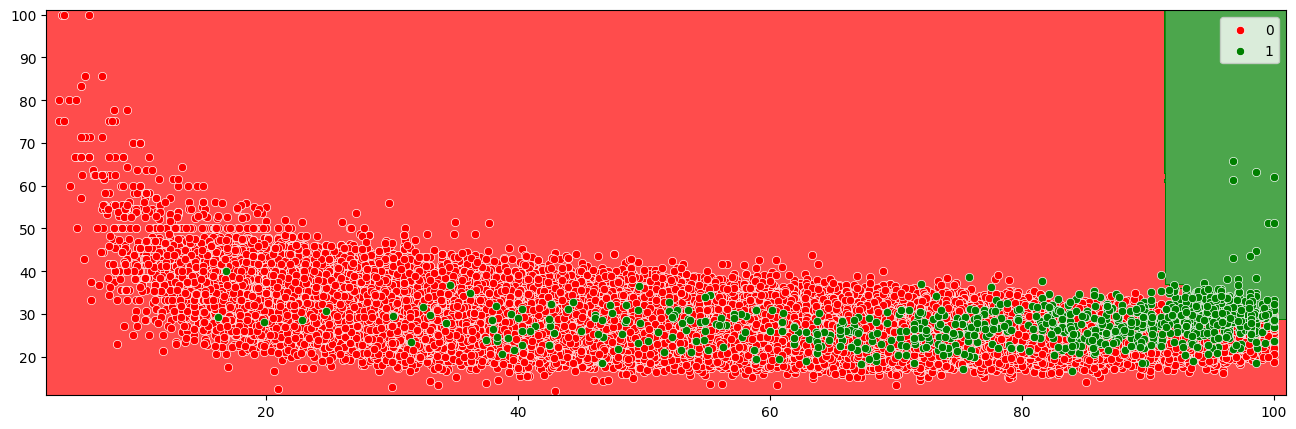

In [60]:
X_train2D = X_train.iloc[:,:2]
y_train = y_train

enn = EditedNearestNeighbours(sampling_strategy='auto',
                              n_neighbors=5,
                              kind_sel='all',
                              n_jobs=-1)

X_resampled, y_resampled = enn.fit_resample(X_train2D, y_train)

rf_oss = RandomForestClassifier(max_depth=4)

rf_oss.fit(X_resampled, y_resampled)

plt.figure(figsize=(16,5))
X_set, y_set = X_resampled.values, y_resampled

colors=('red', 'green')
cmap=ListedColormap(colors)


X1_min, X1_max = X_set[:,0].min() - 1, X_set[:,0].max() + 1
X2_min, X2_max = X_set[:,1].min() - 1, X_set[:,1].max() + 1
step=0.01

X1, X2 = np.meshgrid(
                    np.arange(X1_min, X1_max, step),
                    np.arange(X2_min, X2_max, step)
)


arr = np.array([X1.ravel(), X2.ravel()])
Z = rf_oss.predict(arr.T)
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.7, cmap=cmap)

for i, j in enumerate(np.unique(y_set)):

    xi = X_set[y_set==j,0]
    yi = X_set[y_set==j,1]

    sns.scatterplot(x=xi, y=yi, c=colors[i], label=j)

In [61]:
?SVC

Init signature:
SVC(
    *,
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=False,
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=-1,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=None,
)
Docstring:     
C-Support Vector Classification.

The implementation is based on libsvm. The fit time scales at least
quadratically with the number of samples and may be impractical
beyond tens of thousands of samples. For large datasets
consider using :class:`~sklearn.svm.LinearSVC` or
:class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
:class:`~sklearn.kernel_approximation.Nystroem` transformer or
other :ref:`kernel_approximation`.

The multiclass support is handled according to a one-vs-one scheme.

For details on the precise mathematical formulation of the provided
kernel functions and how `gamma`, `coef0` and `degree` affect each
other, see the

In [ ]:
X_train2D = X_train.iloc[:,:2]
y_train = y_train

enn = EditedNearestNeighbours(sampling_strategy='auto',
                              n_neighbors=5,
                              kind_sel='all',
                              n_jobs=-1)

X_resampled, y_resampled = enn.fit_resample(X_train2D, y_train)

rf_oss = SVC(C=1, gamma=1)

rf_oss.fit(X_resampled, y_resampled)

plt.figure(figsize=(16,5))
X_set, y_set = X_resampled.values, y_resampled

colors=('red', 'green')
cmap=ListedColormap(colors)


X1_min, X1_max = X_set[:,0].min() - 1, X_set[:,0].max() + 1
X2_min, X2_max = X_set[:,1].min() - 1, X_set[:,1].max() + 1
step=0.01

X1, X2 = np.meshgrid(
                    np.arange(X1_min, X1_max, step),
                    np.arange(X2_min, X2_max, step)
)


arr = np.array([X1.ravel(), X2.ravel()])
Z = rf_oss.predict(arr.T)
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.7, cmap=cmap)

for i, j in enumerate(np.unique(y_set)):

    xi = X_set[y_set==j,0]
    yi = X_set[y_set==j,1]

    sns.scatterplot(x=xi, y=yi, c=colors[i], label=j)

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
